In [28]:
import pandas as pd
import scipy as sp
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.graphics.gofplots import qqplot
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

## Задача 1
Заредете данните от файла "newspaper_ads.xls" в "data" папката. Поправете правописната грешка в стойността за четвъртък.

In [29]:
df = pd.read_excel('data/newspaper_ads.xls')
df

,Day,News,Business,Sports
0,Monday,11,10,4
1,NaN,8,12,3
2,NaN,6,13,5
3,NaN,8,11,6
4,Tuesday,9,7,5
5,NaN,10,8,8
6,NaN,10,11,6
7,NaN,12,9,7
8,Wednesday,8,7,5
9,NaN,9,8,9


In [30]:
df.iloc[12, 0] = 'Thursday'

## Задача 2
Трансформирайте данните в подходящ формат за ANOVA.
- В колоната "Day" трябва да имаме деня на всеки ред
- Трябва на всеки ред да имаме по 1 наблюдение, т.е. колоните News 	Business и Sports трябва да станат стойности в една колона 

In [31]:
# Запълваме NaN стойностите с последната налична стойност (forward fill)
df['Day'] = df['Day'].ffill()

# Преобразуваме данните от широк формат в дълъг формат (`melt` e обратната операция на `pivot`)
df_anova = df.melt(
    id_vars=['Day'], # Колоните които остават непроменени, редовете ще бъдат повторени за всяка от разложените колони
    var_name='Type', # Името на новата колона, която съдържа разложените колони
    value_name='Count', # Името на новата колона, която съдържа стойностите от разложените колони
    # value_vars=['News', 'Business', 'Sports'], # Колоните, които ще се разложат в дълъг формат. В случая този параметър е излишен, защото се подразбира, че са всички останали колони.
)
df_anova

,Day,Type,Count
0,Monday,News,11
1,Monday,News,8
2,Monday,News,6
3,Monday,News,8
4,Tuesday,News,9
5,Tuesday,News,10
6,Tuesday,News,10
7,Tuesday,News,12
8,Wednesday,News,8
9,Wednesday,News,9


## Задача 3

- Начертайте boxplot на стойностите за различните типове реклами
- Начертайте boxplot на стойностите за различните дни
- Начертайте boxplot на стойностите едновременно за различните типове реклами и различните дни

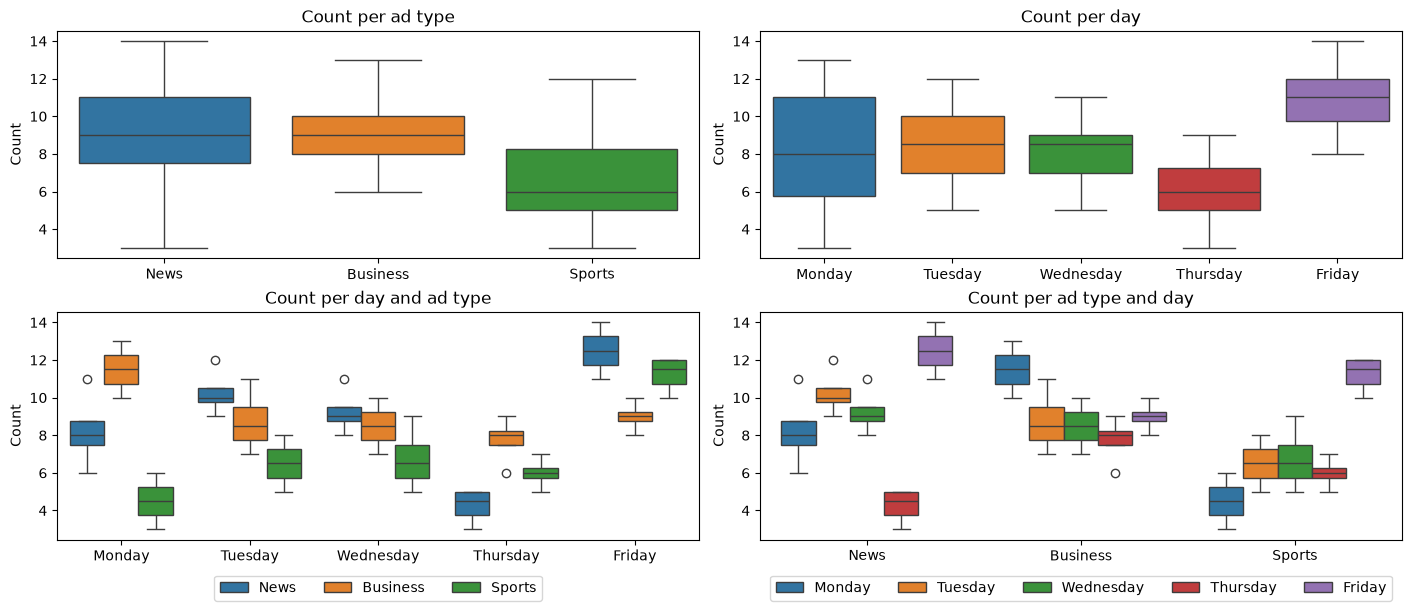

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), layout='constrained') # Изобразяване на 3 графики на един ред

# Брой реклами от различен тип
sb.boxplot(
    df_anova,
    x='Type',
    y='Count',
    hue='Type',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Count per ad type')
axes[0, 0].set_xlabel(None)

# Брой реклами от различни дни
sb.boxplot(
    df_anova,
    x='Day',
    y='Count',
    hue='Day',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Count per day')
axes[0, 1].set_xlabel(None)

# Брой реклами от различни дни по тип
sb.boxplot(
    df_anova,
    x='Day',
    y='Count',
    hue='Type',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Count per day and ad type')
axes[1, 0].set_xlabel(None)
axes[1, 0].legend(bbox_to_anchor=(0.5, -0.3), loc='lower center', ncol=3)

# Брой реклами от различен тип по дни
sb.boxplot(
    df_anova,
    x='Type',
    y='Count',
    hue='Day',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Count per ad type and day')
axes[1, 1].set_xlabel(None)
axes[1, 1].legend(bbox_to_anchor=(0.5, -0.3), loc='lower center', ncol=5)

Забележете, че колкото е по-голям броя на изобразените данни, толково по-трудна става графиката за интерпретация.
Често в такъв случай е по-добре да не замръсяваме визуалицията с много различни цветове.

Сега ще се опитаме да направим графиките по-четливи, като:
> 1. В графиките с една група, ще обозначим нивата на средните стойности използвайки градиент на синия цвят. По-тъмно значи по висока стойност.
> 2. В графиките с две групи, ще използваме градиент от по-сходни цветове за групите и ще се опитаме да увеличим разстояните между групата на дните и групата на типовете. 

In [33]:
# Приготвяме функция за нормализиранe на цветове спрямо максималната и минималната стойност на средните в една група.
def get_normalized_cmap_per_category(group_col, value_col):
    means = df_anova.groupby([group_col])[value_col].mean()
    norm = mcolors.Normalize(vmin=means.min()-1, vmax=means.max()+1)
    cmap = plt.get_cmap('Blues')
    palette = {type: cmap(norm(mean)) for type, mean in means.items()}
    return palette

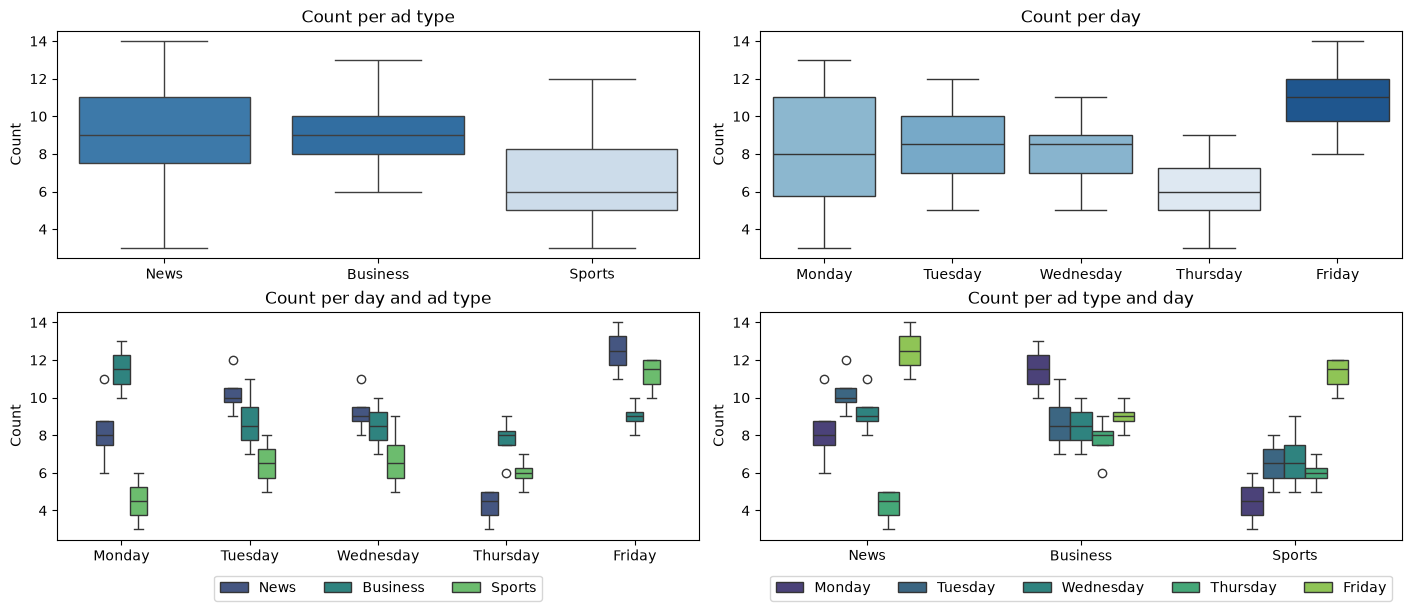

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), layout='constrained') # Изобразяване на 3 графики на един ред

# В първите две графики Х оста е една променлива и категориите са изписани там. 
# Няма нужда да повтаряме същото описание чрез цветовете. 
# По-добре да използваме цвета за да обозначим големината на броя на рекламите.

type_palette = get_normalized_cmap_per_category('Type', 'Count')

sb.boxplot(
    df_anova,
    x='Type',
    y='Count',
    ax=axes[0, 0],
    hue='Type',
    palette=type_palette,
)
axes[0, 0].set_title('Count per ad type')
axes[0, 0].set_xlabel(None)
axes[1, 1].set_xlabel(None)


day_palette = get_normalized_cmap_per_category('Day', 'Count')

sb.boxplot(
    df_anova,
    x='Day',
    y='Count',
    ax=axes[0, 1],
    hue='Day',
    palette=day_palette,
)
axes[0, 1].set_title('Count per day')
axes[0, 1].set_xlabel(None)

# При последните две графики имаме две групи и е по-добре да използваме градиент от цветове, които да са по-сходни.
# Така се вижда по-ясно повторението на категориите от едната група, между категориите на другата група.
# Също така използвайки `width` и `gap` можем да контролираме разстоянието между групите:
#   - `gap=0` означава, че няма разстояние между категориите от вътрешната група
#   - `width=0.4` задава ширината на вътрешната група, така се увеличава разстоянието между външните групи.

sb.boxplot(
    df_anova,
    x='Day',
    y='Count',
    hue='Type',
    ax=axes[1, 0],
    palette='viridis',
    width=0.4,
    gap=0,
)
axes[1, 0].set_title('Count per day and ad type')
axes[1, 0].set_xlabel(None)
axes[1, 0].legend(bbox_to_anchor=(0.5, -0.3), loc='lower center', ncol=3)


sb.boxplot(
    df_anova,
    x='Type',
    y='Count',
    hue='Day',
    ax=axes[1, 1],
    palette='viridis',
    width=0.5,
    gap=0,
)
axes[1, 1].set_title('Count per ad type and day')
axes[1, 1].set_xlabel(None)
axes[1, 1].legend(bbox_to_anchor=(0.5, -0.3), loc='lower center', ncol=5)


## Задача 4 
- Пресметнете средните стойности на броя реклами за всяка комбинация от предиктори
- Начертайте interaction plot на данните

In [35]:
# Средни стойности
df_anova.groupby(['Day', 'Type']).mean()

Count
Day       Type           
Friday    Business   9.00
          News      12.50
          Sports    11.25
Monday    Business  11.50
          News       8.25
          Sports     4.50
Thursday  Business   7.75
          News       4.25
          Sports     6.00
Tuesday   Business   8.75
          News      10.25
          Sports     6.50
Wednesday Business   8.50
          News       9.25
          Sports     6.75

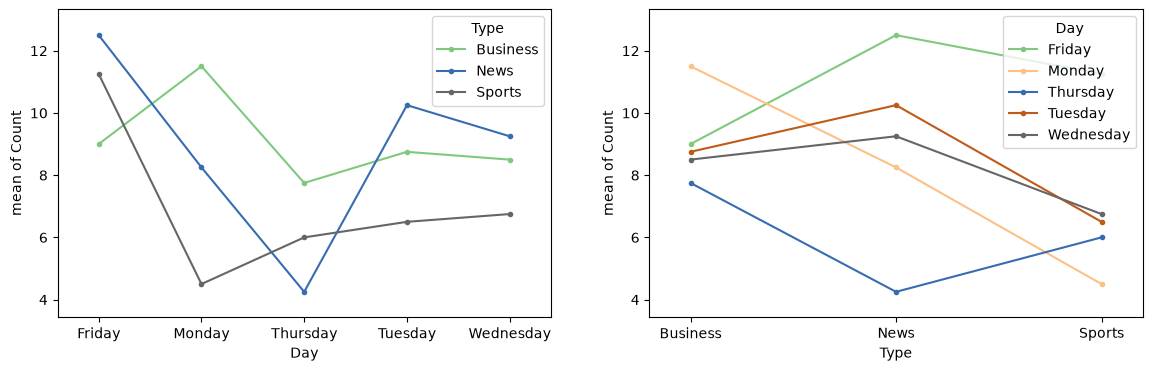

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

fig = interaction_plot(df_anova['Day'], df_anova['Type'], df_anova['Count'], ax=axes[0], colors=plt.cm.Accent(np.linspace(0, 1, len(df_anova['Type'].unique()))))
fig = interaction_plot(df_anova['Type'], df_anova['Day'], df_anova['Count'], ax=axes[1], colors=plt.cm.Accent(np.linspace(0, 1, len(df_anova['Day'].unique()))))

In [37]:
# Без използване на готови функции
def custom_interaction_plot(group_cols, value_col, ax=None):
    if ax is None:
        ax = plt.gca()
        
    means = df_anova.groupby(group_cols)[value_col].mean()

    uniques = means.index.get_level_values(0).unique()
    colors = plt.cm.Accent(np.linspace(0, 1, len(uniques)))

    for type in uniques:
        ax.plot(means[type], label=type, marker='o', color=colors[uniques.get_loc(type)])
        
    ax.set_xlabel(group_cols[1])
    ax.set_ylabel('Mean of count')
    ax.legend(title=group_cols[0])

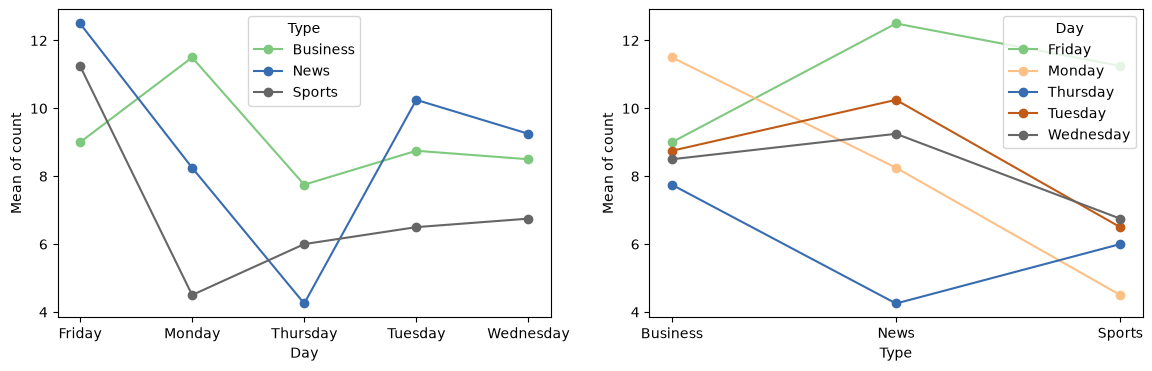

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

custom_interaction_plot(['Type', 'Day'], 'Count', ax=axes[0])
custom_interaction_plot(['Day', 'Type'], 'Count', ax=axes[1])

## Задача 5
Направете ANOVA върху модел на обикновенни най-малки квадрати. Анализирайте резултатите

Моделът на обикновени най-малки квадрати автоматично пресмята F статистиката. Тук тестваната хипотеза е $H_0: \beta_{1} = \beta_{2} = ... = \beta_{j} = 0$. С други думи всички ефекти на променливите са нула. Предположения модел разлага стойността на едно наблюдение като сума от общото средно ($\beta_0$), ефект на променливите и остатък: $\mathbf{Y} = \mathbf{\beta_0 + \beta X + \epsilon}$

F статистиката се смята като дроб на средните суми на квадратите на ефекта и грешката.

$
F = \frac{\frac{SS_{\text{effect}}}{k-1}}{\frac{SS_{\text{res}}}{N-k}} = \frac{MS_{\text{effect}}}{MS_{\text{res}}}
$

Под нулевата хипотеза очакваната стойност на F е равна на 1.

In [39]:
model = ols(formula='Count ~ C(Type)*C(Day)', data=df_anova)
results = model.fit()

print(f'F statistic:    {results.fvalue:.4f}')
print(f'p-value:        {results.f_pvalue:.4e}')

F statistic:    13.6844
p-value:        7.6966e-12


Ние получихме висока F статистика 13.68 с много ниска p-стойност, което означава, че отхвърляме нулевата хипотеза - поне един от коефициентите на линейния модел е различен от нула.




За да оценим всеки от ефектите на променливите по отделно, правим **частичен F тест**. Тук за всеки от факторите, се изгражда отделен модел, където съотвения фактор е премахнат. В последствие се сравнява разликата на средната сума на квадратите от тази на пълния модел. Това ни дава оценка на главния ефект на променливата.

При частичен F тест, нулевата хипотеза е, че премахнатия фактор не допринася за точността на модела.

F статистиката е равна на разликата в сумата от квадратите, осреднена спрямо степените на свобода. Отново, под нулевата хипотеза, очакваната стойност е 1.

$
F_{factor} = \frac{\frac{SS_{\text{effect, without factor}}-SS_{\text{effect, full}}}{(p-1)-(k-1)}}{\frac{SS_{\text{res}}}{N-k}}
$

Функцията `anova_lm` прави това за нас, за всеки от факторите:

In [89]:
sm.stats.anova_lm(results, typ=1)

,df,sum_sq,mean_sq,F,PR(>F)
C(Type),2.0,53.733333,26.866667,15.303797,8.502752e-06
C(Day),4.0,146.833333,36.708333,20.909810,8.517535e-10
C(Type):C(Day),8.0,135.766667,16.970833,9.666930,1.124687e-07
Residual,45.0,79.000000,1.755556,NaN,NaN


In [70]:
sm.stats.anova_lm(results, typ=2)

,sum_sq,df,F,PR(>F)
C(Type),53.733333,2.0,15.303797,8.502752e-06
C(Day),146.833333,4.0,20.909810,8.517535e-10
C(Type):C(Day),135.766667,8.0,9.666930,1.124687e-07
Residual,79.000000,45.0,NaN,NaN


In [ ]:
model_typ3 = ols(formula="Count ~ C(Type, Sum)*C(Day, Sum)", data=df_anova) # За тип 3 анова трябва да премахнем референтната категория чрез Sum-to-Zero кодиране на категориите
results_typ3 = model_typ3.fit()

sm.stats.anova_lm(results_typ3, typ=3)

,sum_sq,df,F,PR(>F)
Intercept,4166.666667,1.0,2373.417722,1.395249e-40
"C(Type, Sum)",53.733333,2.0,15.303797,8.502752e-06
"C(Day, Sum)",146.833333,4.0,20.909810,8.517535e-10
"C(Type, Sum):C(Day, Sum)",135.766667,8.0,9.666930,1.124687e-07
Residual,79.000000,45.0,NaN,NaN


В нашия случай данните са балансирани (еднакъв брой данни в групите), което означава, че всеки тип ANOVA дава еднакъв резултат.

## Задача 6
Тествайте грешките за нормалност
- начертайте хистограма
- начертайте qqplot
- направете тест на Шапиро-Уилк

<Axes: >

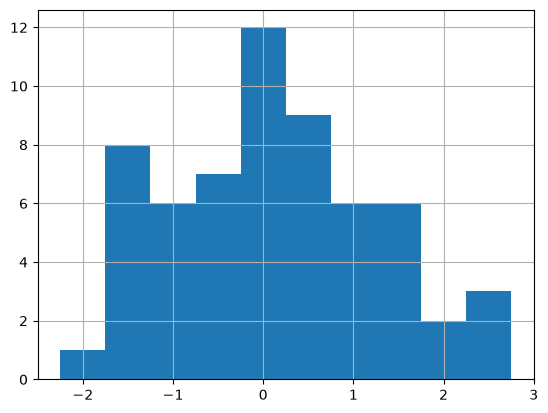

In [83]:
results.resid.hist()

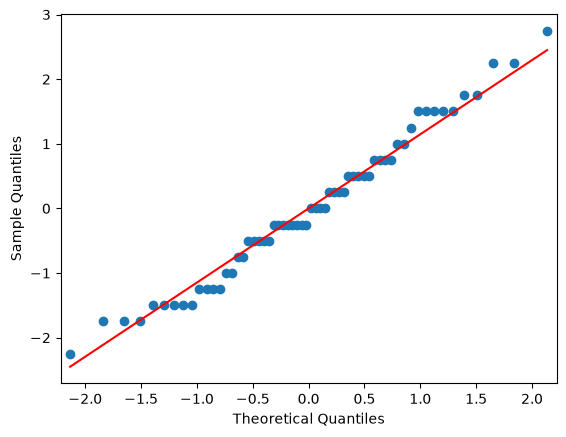

In [86]:
plot = qqplot(results.resid, line='s')

In [88]:
sp.stats.shapiro(results.resid)

ShapiroResult(statistic=np.float64(0.9769865836176984), pvalue=np.float64(0.31468554895458156))